# Landmark SLAM: F Function Tests

Verification tests for the SLAM filter update `F` using a landmark map and range-bearing sensor.

In [1]:
import sys
import os
import subprocess
from pathlib import Path

# Ensure project import path
PROJECT_ROOT = Path('/global/home/hpc5656/SLAM')
sys.path.append(str(PROJECT_ROOT))
# Set working directory so relative paths (e.g., src/config/*.yaml) resolve
os.chdir(str(PROJECT_ROOT))
print('CWD:', Path.cwd())

%matplotlib inline

# Enable autoreload for development (automatically reloads modules when they change)
%load_ext autoreload
%autoreload 2

# =============================================================================
# CRITICAL: Preload libcuda.so.1 from system path BEFORE anything else
# DGX nodes have the driver in /usr/lib64 but cuda-python can't find it
# =============================================================================
import ctypes
try:
    ctypes.CDLL("/usr/lib64/libcuda.so.1", mode=ctypes.RTLD_GLOBAL)
    print("✓ Preloaded libcuda.so.1 from /usr/lib64")
except Exception as e:
    print(f"⚠ Could not preload libcuda.so.1: {e}")

# CuPy is required - ensure CUDA_PATH and LD_LIBRARY_PATH are set
# This allows the notebook to work even if Jupyter wasn't started with modules loaded
if "CUDA_PATH" not in os.environ:
    print("CUDA_PATH not set, attempting to load modules...")
    try:
        result = subprocess.run(
            'module load cuda/12.2 && env',
            shell=True,
            executable='/bin/bash',
            capture_output=True,
            text=True,
            timeout=10
        )
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if '=' in line:
                    key, value = line.split('=', 1)
                    os.environ[key] = value
            print(f"✓ Modules loaded. CUDA_PATH: {os.environ.get('CUDA_PATH', 'Not set')}")
        else:
            print(f"⚠ Could not load modules. Error: {result.stderr}")
            raise RuntimeError(
                "CUDA_PATH not set and could not load modules. "
                "Please run: module load cuda/12.2 before starting Jupyter."
            )
    except Exception as e:
        print(f"✗ Could not load modules: {e}")
        raise RuntimeError(
            f"Failed to load CUDA modules: {e}\n"
            "Please ensure CUDA is loaded before starting Jupyter:\n"
            "  module load cuda/12.2"
        ) from e

# Ensure LD_LIBRARY_PATH includes CUDA library directory for NVRTC (libnvrtc.so.12)
# This is required for CuPy to compile kernels at runtime
# Note: Setting this BEFORE importing CuPy is critical
cuda_path = os.environ.get('CUDA_PATH')
libnvrtc_path = None

if cuda_path:
    # Check both standard location and Compute Canada's targets/x86_64-linux/lib location
    cuda_lib_paths = [
        os.path.join(cuda_path, 'lib64'),  # Standard location
        os.path.join(cuda_path, 'targets', 'x86_64-linux', 'lib'),  # Compute Canada location
    ]
    
    current_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    ld_paths = current_ld_path.split(':') if current_ld_path else []
    paths_added = []
    
    # Find which paths exist and add them to LD_LIBRARY_PATH
    for cuda_lib_path in cuda_lib_paths:
        if os.path.exists(cuda_lib_path):
            if cuda_lib_path not in ld_paths:
                paths_added.append(cuda_lib_path)
                ld_paths.insert(0, cuda_lib_path)  # Prepend for priority
    
    if paths_added:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(ld_paths)
        print(f"✓ Updated LD_LIBRARY_PATH to include: {', '.join(paths_added)}")
    else:
        # Check if paths were already included
        found_paths = [p for p in cuda_lib_paths if p in ld_paths]
        if found_paths:
            print(f"✓ LD_LIBRARY_PATH already includes CUDA libraries: {', '.join(found_paths)}")
    
    # Preload CUDA runtime libraries
    libcudart_path = None
    
    for cuda_lib_path in cuda_lib_paths:
        if os.path.exists(cuda_lib_path):
            # Look for libcudart.so (CUDA runtime - required for CuPy initialization)
            potential_libcudart = os.path.join(cuda_lib_path, 'libcudart.so')
            if os.path.exists(potential_libcudart) and libcudart_path is None:
                libcudart_path = potential_libcudart
                print(f"✓ Found libcudart.so at: {libcudart_path}")
                try:
                    ctypes.CDLL(libcudart_path, mode=ctypes.RTLD_GLOBAL)
                    print(f"✓ Preloaded libcudart.so using ctypes (RTLD_GLOBAL)")
                except Exception as e:
                    print(f"⚠ Warning: Could not preload libcudart.so: {e}")
            
            # Also try versioned libcudart.so.12
            potential_libcudart_12 = os.path.join(cuda_lib_path, 'libcudart.so.12')
            if os.path.exists(potential_libcudart_12) and libcudart_path is None:
                libcudart_path = potential_libcudart_12
                print(f"✓ Found libcudart.so.12 at: {libcudart_path}")
                try:
                    ctypes.CDLL(libcudart_path, mode=ctypes.RTLD_GLOBAL)
                    print(f"✓ Preloaded libcudart.so.12 using ctypes (RTLD_GLOBAL)")
                except Exception as e:
                    print(f"⚠ Warning: Could not preload libcudart.so.12: {e}")
            
            # Look for libnvrtc.so.12 (NVRTC compiler - for kernel compilation)
            potential_libnvrtc = os.path.join(cuda_lib_path, 'libnvrtc.so.12')
            if os.path.exists(potential_libnvrtc) and libnvrtc_path is None:
                libnvrtc_path = potential_libnvrtc
                print(f"✓ Found libnvrtc.so.12 at: {libnvrtc_path}")
                try:
                    ctypes.CDLL(libnvrtc_path, mode=ctypes.RTLD_GLOBAL)
                    print(f"✓ Preloaded libnvrtc.so.12 using ctypes (RTLD_GLOBAL)")
                except Exception as e:
                    print(f"⚠ Warning: Could not preload libnvrtc.so.12: {e}")
    
    if not libcudart_path:
        print("⚠ Warning: libcudart.so not found - CuPy may fail to initialize")
    if not libnvrtc_path:
        print("⚠ Warning: libnvrtc.so.12 not found - CuPy kernel compilation may fail")
else:
    print("⚠ CUDA_PATH not set, cannot configure LD_LIBRARY_PATH")

# Diagnostic: Print environment before importing CuPy
print("\n=== Environment before CuPy import ===")
print(f"CUDA_PATH: {os.environ.get('CUDA_PATH', 'Not set')}")
print(f"LD_LIBRARY_PATH: {os.environ.get('LD_LIBRARY_PATH', 'Not set')[:200]}...")  # Truncate if too long
print("=====================================\n")

# Use CuPy backend for GPU acceleration (falls back to NumPy if not available)
from src.utils.array_backend import np, random, is_cupy
from src.classes.belief_mdp_n import BeliefMDP_n_SLAM
import numpy as np_cpu  # Import NumPy explicitly for CPU operations
from src.classes.mapping import OrderedLandmarkMap
from src.classes.model import RangeBearingSensor, DoubleIntegratorModel

print("✓ All imports successful")

# Diagnostic: Check CuPy initialization and CUDA availability
if is_cupy:
    print("Using backend: CuPy (GPU)")
    try:
        import cupy as cp
        print(f"✓ CuPy version: {cp.__version__}")
        print(f"✓ CUDA version: {cp.cuda.runtime.runtimeGetVersion()}")
        device_count = cp.cuda.runtime.getDeviceCount()
        print(f"✓ CUDA devices available: {device_count}")
        for i in range(device_count):
            props = cp.cuda.runtime.getDeviceProperties(i)
            print(f"  Device {i}: {props['name'].decode() if isinstance(props['name'], bytes) else props['name']}")
        current_device = cp.cuda.Device()
        print(f"✓ Current device: {current_device.id}")
    except Exception as e:
        print(f"✗ CuPy initialization check failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Using backend: NumPy (CPU)")
    # Try to diagnose why CuPy failed
    try:
        import cupy as cp_test
        print("⚠ CuPy is installed but not being used. Testing initialization...")
        try:
            test_arr = cp_test.array([1, 2, 3])
            print(f"✓ CuPy test array creation succeeded: {test_arr}")
            print("⚠ But array_backend reported CuPy unavailable - check import order")
        except Exception as cupy_err:
            print(f"✗ CuPy test failed: {type(cupy_err).__name__}: {cupy_err}")
            import traceback
            traceback.print_exc()
    except ImportError:
        print("⚠ CuPy not installed")

CWD: /global/home/hpc5656/SLAM
✓ Preloaded libcuda.so.1 from /usr/lib64
CUDA_PATH not set, attempting to load modules...
✓ Modules loaded. CUDA_PATH: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2
✓ Updated LD_LIBRARY_PATH to include: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/lib64, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/targets/x86_64-linux/lib
✓ Found libcudart.so at: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/lib64/libcudart.so
✓ Preloaded libcudart.so using ctypes (RTLD_GLOBAL)
✓ Found libnvrtc.so.12 at: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/lib64/libnvrtc.so.12
✓ Preloaded libnvrtc.so.12 using ctypes (RTLD_GLOBAL)

=== Environment before CuPy import ===
CUDA_PATH: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2
LD_LIBRARY_PATH: /cvmfs/sof

In [17]:
# Landmark map setup
workspace_min = 0.0
workspace_max = 10.0

# Quantized landmark positions: X_n (n=3 -> 9 possible locations)
quantization_level = 3
cell_size = (workspace_max - workspace_min) / quantization_level
coords = workspace_min + cell_size * (np.arange(quantization_level) + 0.5)
xx, yy = np.meshgrid(coords, coords)
landmark_positions = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Ordered landmark tuples: map space is M = X_n^3
_map = OrderedLandmarkMap(
    x_min=workspace_min,
    x_max=workspace_max,
    y_min=workspace_min,
    y_max=workspace_max,
    landmark_positions=landmark_positions,
    num_landmarks=3,
)

motion_model = DoubleIntegratorModel(p_x=5.0, p_y=5.0, v_x=0.0, v_y=0.0, dt=1.0, max_a=1.0)
sensor = RangeBearingSensor(r_max=6.0, epsilon=0.1, sigma_r=0.05, sigma_phi=0.05)

bmdp = BeliefMDP_n_SLAM(
    n=3,
    motion_model=motion_model,
    measurement_model=sensor,
    obstacles=[],
    _map=_map,
    sigma_w=0.01,
    sigma_v=0.01,
    exploration_type="information gain",
    obs_n=5,  # Observation quantization (n + 2 = 5)
    action_n=4,  # Separate quantization level for action space (more nuanced control)
)

# Convert Q_n to CuPy if using GPU backend (Q_n is loaded/computed as NumPy)
if is_cupy and bmdp.Q_n is not None:
    import cupy as cp
    if not isinstance(bmdp.Q_n, cp.ndarray):
        print("Converting Q_n from NumPy to CuPy...")
        bmdp.Q_n = cp.asarray(bmdp.Q_n)

print("State grid size (m_n):", bmdp.SQ.m_n)
print("Map hypothesis count (len_M):", bmdp.len_M)
print("Observation quantization (obs_n):", bmdp.obs_n)
print("Observation dim:", bmdp.Y_n.shape[1])
if bmdp.Q_n is not None:
    print(f"Q_n shape: {bmdp.Q_n.shape}")
    print(f"Q_n dtype: {bmdp.Q_n.dtype}")
    if is_cupy:
        import cupy as cp
        print(f"Q_n backend: {'CuPy' if isinstance(bmdp.Q_n, cp.ndarray) else 'NumPy'}")
    else:
        print(f"Q_n backend: NumPy")

Computing T_mat for the first time...


Computing T_mat:   0%|          | 0/16 [00:00<?, ?it/s]

Saved T_mat to /global/home/hpc5656/SLAM/cache/T_mat/T_mat_n3_map3x2_max1.0_69ad8ac8.npz
  Checking cache file: Q_n_n3_obs5_map3x2_L3_b456fb80.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs5_map3x2_L3_b456fb80.npz
State grid size (m_n): 81
Map hypothesis count (len_M): 729
Observation quantization (obs_n): 5
Observation dim: 6
Q_n shape: (17576, 81, 729)
Q_n dtype: float64
Q_n backend: CuPy


In [18]:
# Build a joint belief with concentrated state prior and uniform map prior
x_true = np.array([5.0, 5.0, 0.0, 0.0])
state_prior = np.zeros(bmdp.SQ.m_n, dtype=float)
state_idx = bmdp.SQ.get_quantized_index(x_true)
state_prior[state_idx] = 1.0

map_prior = np.ones(bmdp.len_M, dtype=float)
map_prior /= map_prior.sum()

pi = np.outer(state_prior, map_prior)
pi /= np.sum(pi)

# Sanity check: state and map marginals
state_marginal = pi.sum(axis=1)
map_marginal = pi.sum(axis=0)
print("State prior nonzero count:", int(np.count_nonzero(state_marginal)))
print("Map prior mean/std:", float(map_marginal.mean()), float(map_marginal.std()))

# True pose and true map (all landmarks present)
# DoubleIntegratorModel uses 4D state: (p_x, p_y, v_x, v_y)
true_map = np.array([0, 1, 2], dtype=int)
true_landmarks = _map.get_landmark_positions(true_map)

# Generate a noise-free observation and flatten to match Y_n dimension
obs = sensor.g_bar(x_true, true_landmarks)  # (num_landmarks, 2)
if np.any(np.isnan(obs)):
    raise ValueError("Observation contains NaNs; choose a pose with all landmarks visible.")
y = obs.reshape(-1)

# Quantize observation to nearest grid cell (consistent with Q_n bins)
obs_idx = bmdp._find_observation_indices(np.array([y]))[0]
y = bmdp.Y_n[obs_idx]

# Sample action (use quantized action for consistency with T_mat)
u = np.array([0.5, -0.25])
uidx = bmdp.AQ.get_quantized_index(u)
u_q = bmdp.AQ.U[uidx]

# Compare F and F_batch_log
pi_new_single = bmdp.F(pi, u_q, y)[0]
pi_new_batch = bmdp.F_batch_log(pi, u_q, np.array([y]))[0]

print("pi_new_single sum:", float(np.sum(pi_new_single)))
print("pi_new_batch  sum:", float(np.sum(pi_new_batch)))
print("L2 diff:", float(np.linalg.norm(pi_new_single - pi_new_batch)))

State prior nonzero count: 1
Map prior mean/std: 0.0013717421124828531 0.0
pi_new_single sum: 1.0
pi_new_batch  sum: 1.0
L2 diff: 0.0


## Landmark Belief GIF

Animate landmark presence probabilities over time.

In [25]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Verify all_maps_3d has correct ordering (if not, clear cache and regenerate)
import numpy as np_cpu
true_map = np.array([0, 1, 2], dtype=int)
true_map_id = _map.map_to_id(true_map)
expected_landmarks = _map.get_landmark_positions(true_map)
expected_landmarks = expected_landmarks.get() if hasattr(expected_landmarks, 'get') else np_cpu.asarray(expected_landmarks)

all_maps_3d_np = bmdp.all_maps_3d.get() if hasattr(bmdp.all_maps_3d, 'get') else np_cpu.asarray(bmdp.all_maps_3d)
cached_map_11 = all_maps_3d_np[true_map_id]

print(f"Checking all_maps_3d ordering...")
print(f"  true_map_id={true_map_id}, true_map={true_map}")
print(f"  Expected landmarks: {expected_landmarks}")
print(f"  Cached landmarks: {cached_map_11}")

if not np_cpu.allclose(expected_landmarks, cached_map_11, atol=1e-6):
    print(f"⚠ all_maps_3d has wrong ordering! Clearing cache and regenerating...")
    from pathlib import Path
    cache_path = bmdp._get_all_maps_cache_path()
    if cache_path.exists():
        cache_path.unlink()
        print(f"  Deleted all_maps cache: {cache_path}")
    # Note: Q_n cache does NOT need to be deleted - it doesn't depend on map ordering
    # Only all_maps_3d ordering matters, and Q_n will work correctly once all_maps_3d is fixed
    bmdp.all_maps_3d, bmdp.map_bits_array = bmdp._load_or_generate_all_maps()
    # Ensure Q_n is loaded/computed if it's None
    if bmdp.Q_n is None:
        Q_cache_path = bmdp._get_Q_cache_path()
        if not bmdp._load_Q_n(Q_cache_path):
            print("  Computing Q_n (cache not found or invalid)...")
            bmdp.Q_n = bmdp._compute_Q_n()
            bmdp._save_Q_n(Q_cache_path)
            print(f"  Saved Q_n to {Q_cache_path}")
    print(f"✓ Regenerated all_maps_3d (Q_n cache preserved)")
    # Verify it's correct now
    all_maps_3d_np = bmdp.all_maps_3d.get() if hasattr(bmdp.all_maps_3d, 'get') else np_cpu.asarray(bmdp.all_maps_3d)
    cached_map_11 = all_maps_3d_np[true_map_id]
    print(f"  After regeneration: {cached_map_11}")
    if np_cpu.allclose(expected_landmarks, cached_map_11, atol=1e-6):
        print(f"✓ Verified all_maps_3d[{true_map_id}] now has correct landmarks")
    else:
        print(f"✗ Still wrong after regeneration! Debugging...")
        # Check what idx_grid[11] actually is
        N, l = 9, 3
        coords = [np_cpu.arange(N) for _ in range(l)]
        mesh = np_cpu.meshgrid(*coords, indexing='ij')
        idx_grid = np_cpu.stack([m.ravel() for m in mesh], axis=1)
        print(f"  idx_grid[11] = {idx_grid[11]}")
        print(f"  landmark_positions[idx_grid[11]] = {landmark_positions.get() if hasattr(landmark_positions, 'get') else landmark_positions}[{idx_grid[11]}]")
        print(f"  This is a bug in generate_all_maps() - need to fix ordering")
else:
    print(f"✓ all_maps_3d has correct ordering")

# Simple rollout to build belief history
n_steps = 12
# Use a quantized action directly (not a continuous one that gets quantized to zero)
# Get all quantized actions and their magnitudes
import numpy as np_cpu
all_actions = bmdp.AQ.U.get() if hasattr(bmdp.AQ.U, 'get') else np_cpu.asarray(bmdp.AQ.U)
all_actions = np_cpu.asarray(all_actions)  # Ensure it's NumPy
magnitudes = np_cpu.linalg.norm(all_actions, axis=1)

# Find actions with meaningful magnitude (lower threshold to catch more actions)
threshold = 1e-3  # Lower threshold to catch actions that aren't exactly zero
non_zero_mask = magnitudes > threshold
non_zero_actions = all_actions[non_zero_mask]

if len(non_zero_actions) > 0:
    # Use the action with the largest magnitude (most significant control)
    best_idx = np_cpu.argmax(magnitudes[non_zero_mask])
    u_q_direct = non_zero_actions[best_idx].copy()  # Make a copy
    u_seq = [u_q_direct.copy() for _ in range(n_steps)]  # Create separate copies
    use_quantized_directly = True  # Flag to skip re-quantization
    print(f"Using quantized action directly: {u_q_direct} (magnitude: {magnitudes[non_zero_mask][best_idx]:.4f})")
    print(f"Available {len(non_zero_actions)} non-zero actions (out of {len(all_actions)} total)")
    print(f"Top 5 action magnitudes: {sorted(magnitudes[non_zero_mask], reverse=True)[:5]}")
else:
    # Fallback: use a larger continuous control and let it quantize
    u_seq = [np.array([1.0, -0.5])] * n_steps
    use_quantized_directly = False
    print(f"Warning: no non-zero quantized actions found (threshold={threshold})")
    print(f"All action magnitudes: {magnitudes}")
    print(f"Using continuous control: {u_seq[0]} (will be quantized)")

# Initialize belief and state (state prior concentrated at truth)
x_true = np.array([5.0, 5.0, 0.0, 0.0])
state_prior = np.zeros(bmdp.SQ.m_n, dtype=float)
state_idx = bmdp.SQ.get_quantized_index(x_true)
state_prior[state_idx] = 1.0

map_prior = np.ones(bmdp.len_M, dtype=float)
map_prior /= map_prior.sum()

pi = np.outer(state_prior, map_prior)
pi /= np.sum(pi)

true_landmarks = _map.get_landmark_positions(true_map)

belief_history = [pi]
positions = [x_true[:2].copy()]
x_history = [x_true.copy()]
obs_history = []
visibility_counts = []

print(f"\nStarting rollout with {n_steps} steps...")
# Debug: check action quantizer
print(f"Action quantizer: n={bmdp.AQ.n}, max_acc={bmdp.AQ.max_acc}, n_actions={len(bmdp.AQ.U)}")

for t, u in enumerate(u_seq):
    if use_quantized_directly:
        # Already using quantized actions, use directly without re-quantizing
        u_q = np_cpu.asarray(u)  # u is already a NumPy array from our selection
    else:
        # Quantize the continuous action
        uidx = bmdp.AQ.get_quantized_index(u)
        u_q = bmdp.AQ.U[uidx]
        u_q = u_q.get() if hasattr(u_q, 'get') else np_cpu.asarray(u_q)
    
    # Convert to CuPy if using GPU backend (motion_model expects CuPy arrays)
    if is_cupy:
        import cupy as cp
        u_q = cp.asarray(u_q)
    
    if t == 0:
        u_q_display = u_q.get() if hasattr(u_q, 'get') else np_cpu.asarray(u_q)
        print(f"t=0: u={u}, u_q={u_q_display}, magnitude={np_cpu.linalg.norm(u_q_display):.6f}, use_quantized_directly={use_quantized_directly}")
    x_true_prev = x_true.copy()
    x_true = motion_model.f_bar(x_true, u_q)
    # Debug: verify f_bar computation
    if t < 2:
        x_nom_manual = x_true_prev @ motion_model.A.T + motion_model.B @ u_q
        print(f"  DEBUG t={t}: x_prev={x_true_prev}, u_q={u_q}")
        print(f"  DEBUG t={t}: x_nom_manual={x_nom_manual}, x_true_after_f_bar={x_true}")
        print(f"  DEBUG t={t}: dt={motion_model.dt}, A shape={motion_model.A.shape}, B shape={motion_model.B.shape}")
    obs = sensor.g_bar(x_true, true_landmarks)  # (num_landmarks, 2) with NaNs for ⟂
    y = obs.reshape(-1)
    obs_idx = bmdp._find_observation_indices(np.array([y]))[0]
    y = bmdp.Y_n[obs_idx]
    pi_prev = pi.copy()
    pi = bmdp.F(pi, u_q, y)[0]
    pi_cpu = pi.get() if hasattr(pi, 'get') else np.asarray(pi)
    belief_history.append(pi_cpu)
    positions.append(x_true[:2].copy())
    x_history.append(x_true.copy())
    obs_history.append(obs)
    visibility_counts.append(int(np.sum(~np.isnan(obs[:, 0]))))
    
    # Debug: print movement and belief change
    if t < 3 or t == n_steps - 1:
        pos_change = np.linalg.norm(x_true[:2] - x_true_prev[:2])
        belief_change = np.linalg.norm(pi_cpu - (pi_prev.get() if hasattr(pi_prev, 'get') else np.asarray(pi_prev)))
        print(f"t={t}: u={u}, u_q={u_q}, x_prev={x_true_prev[:2]}, x_new={x_true[:2]}, pos_change={pos_change:.4f}, belief_change={belief_change:.6f}, obs_idx={obs_idx}")

    if t == 0:
        map_marginal = pi_cpu.sum(axis=0)
        map_marginal = map_marginal / map_marginal.sum()
        top_ids = np.argsort(map_marginal)[-5:][::-1]
        print("t=0 obs_idx:", int(obs_idx))
        print("t=0 true_map_id:", int(true_map_id), "prob:", float(map_marginal[true_map_id]))
        print("t=0 top map ids:", top_ids.tolist())
        print("t=0 top map probs:", [float(map_marginal[i]) for i in top_ids])

print("Steps:", len(belief_history) - 1)
print("Visible landmark counts per step:", visibility_counts)

# Diagnostics: compare MAP candidate per landmark vs true
import numpy as np_cpu

M = bmdp.all_maps_3d
M = M.get() if hasattr(M, 'get') else np_cpu.asarray(M)
candidate_positions = bmdp.map.landmark_positions
candidate_positions = candidate_positions.get() if hasattr(candidate_positions, 'get') else np_cpu.asarray(candidate_positions)

true_landmarks_np = true_landmarks.get() if hasattr(true_landmarks, 'get') else np_cpu.asarray(true_landmarks)
true_idx = []
for i in range(true_landmarks_np.shape[0]):
    diffs = candidate_positions - true_landmarks_np[i]
    true_idx.append(int(np_cpu.argmin(np_cpu.linalg.norm(diffs, axis=1))))
print("True candidate indices:", true_idx)

# Map each map's landmark positions to candidate indices
num_landmarks = int(getattr(bmdp.map, 'num_landmarks', M.shape[1]))
diffs = M[:, :, np_cpu.newaxis, :] - candidate_positions[np_cpu.newaxis, np_cpu.newaxis, :, :]
idx = np_cpu.argmin(np_cpu.linalg.norm(diffs, axis=3), axis=2)  # (len_M, l)

for t, pi_step in enumerate(belief_history):
    map_marginal = pi_step.sum(axis=0)
    map_marginal = map_marginal / map_marginal.sum()
    map_marginal = map_marginal.get() if hasattr(map_marginal, 'get') else np_cpu.asarray(map_marginal)

    # Joint MAP over ordered tuples
    map_map_id = int(np_cpu.argmax(map_marginal))
    joint_tuple = idx[map_map_id]

    for i in range(num_landmarks):
        probs = np_cpu.zeros(candidate_positions.shape[0])
        for m_id, cand in enumerate(idx[:, i]):
            probs[cand] += map_marginal[m_id]
        if t in (0, len(belief_history) - 1):
            print(f"t={t}, L{i+1} MAP idx={int(np_cpu.argmax(probs))}, true idx={true_idx[i]}")

    if t in (0, len(belief_history) - 1):
        print(f"t={t}, joint MAP tuple idx={joint_tuple.tolist()}, true idx={true_idx}")


Checking all_maps_3d ordering...
  true_map_id=11, true_map=[0 1 2]
  Expected landmarks: [[1.66666667 1.66666667]
 [5.         1.66666667]
 [8.33333333 1.66666667]]
  Cached landmarks: [[1.66666667 1.66666667]
 [5.         1.66666667]
 [8.33333333 1.66666667]]
✓ all_maps_3d has correct ordering
Using quantized action directly: [-0.63584344 -0.63584344] (magnitude: 0.8992)
Available 16 non-zero actions (out of 16 total)
Top 5 action magnitudes: [np.float64(0.8992184106211348), np.float64(0.8992184106211348), np.float64(0.8992184106211348), np.float64(0.8992184106211348), np.float64(0.7680128579652818)]

Starting rollout with 12 steps...
Action quantizer: n=4, max_acc=1.0, n_actions=16
t=0: u=[-0.63584344 -0.63584344], u_q=[-0.63584344 -0.63584344], magnitude=0.899218, use_quantized_directly=True
  DEBUG t=0: x_prev=[5. 5. 0. 0.], u_q=[-0.63584344 -0.63584344]
  DEBUG t=0: x_nom_manual=[ 4.68207828  4.68207828 -0.63584344 -0.63584344], x_true_after_f_bar=[ 4.68207828  4.68207828 -0.6358

In [26]:
# Run simulation with UNIFORM state prior (instead of concentrated at truth)
print("=" * 80)
print("SIMULATION WITH UNIFORM STATE PRIOR")
print("=" * 80)

# Use the same action sequence
# (u_seq and use_quantized_directly are already defined from previous cell)

# Initialize belief and state with UNIFORM state prior
x_true_uniform = np.array([5.0, 5.0, 0.0, 0.0])  # True state for generating observations
state_prior_uniform = np.ones(bmdp.SQ.m_n, dtype=float)  # Uniform prior
state_prior_uniform /= state_prior_uniform.sum()

map_prior_uniform = np.ones(bmdp.len_M, dtype=float)
map_prior_uniform /= map_prior_uniform.sum()

pi_uniform = np.outer(state_prior_uniform, map_prior_uniform)
pi_uniform /= np.sum(pi_uniform)

true_landmarks_uniform = _map.get_landmark_positions(true_map)

belief_history_uniform = [pi_uniform.copy()]
positions_uniform = [x_true_uniform[:2].copy()]
x_history_uniform = [x_true_uniform.copy()]
obs_history_uniform = []
visibility_counts_uniform = []

print(f"\nStarting rollout with {n_steps} steps (uniform state prior)...")
print(f"State prior: uniform over {bmdp.SQ.m_n} states")
print(f"Map prior: uniform over {bmdp.len_M} maps")

for t, u in enumerate(u_seq):
    if use_quantized_directly:
        # Already using quantized actions, use directly without re-quantizing
        u_q = np_cpu.asarray(u)  # u is already a NumPy array from our selection
    else:
        # Quantize the continuous action
        uidx = bmdp.AQ.get_quantized_index(u)
        u_q = bmdp.AQ.U[uidx]
        u_q = u_q.get() if hasattr(u_q, 'get') else np_cpu.asarray(u_q)
    
    # Convert to CuPy if using GPU backend (motion_model expects CuPy arrays)
    if is_cupy:
        import cupy as cp
        u_q = cp.asarray(u_q)
    
    if t == 0:
        u_q_display = u_q.get() if hasattr(u_q, 'get') else np_cpu.asarray(u_q)
        print(f"t=0: u={u}, u_q={u_q_display}, magnitude={np_cpu.linalg.norm(u_q_display):.6f}")
    
    x_true_prev_uniform = x_true_uniform.copy()
    x_true_uniform = motion_model.f_bar(x_true_uniform, u_q)
    obs = sensor.g_bar(x_true_uniform, true_landmarks_uniform)  # (num_landmarks, 2) with NaNs for ⟂
    y = obs.reshape(-1)
    obs_idx = bmdp._find_observation_indices(np.array([y]))[0]
    y = bmdp.Y_n[obs_idx]
    pi_prev_uniform = pi_uniform.copy()
    pi_uniform = bmdp.F(pi_uniform, u_q, y)[0]
    pi_cpu_uniform = pi_uniform.get() if hasattr(pi_uniform, 'get') else np.asarray(pi_uniform)
    belief_history_uniform.append(pi_cpu_uniform)
    positions_uniform.append(x_true_uniform[:2].copy())
    x_history_uniform.append(x_true_uniform.copy())
    obs_history_uniform.append(obs)
    visibility_counts_uniform.append(int(np.sum(~np.isnan(obs[:, 0]))))
    
    # Debug: print movement and belief change
    if t < 3 or t == n_steps - 1:
        pos_change = np.linalg.norm(x_true_uniform[:2] - x_true_prev_uniform[:2])
        belief_change = np.linalg.norm(pi_cpu_uniform - (pi_prev_uniform.get() if hasattr(pi_prev_uniform, 'get') else np.asarray(pi_prev_uniform)))
        print(f"t={t}: pos_change={pos_change:.4f}, belief_change={belief_change:.6f}, obs_idx={obs_idx}")

print("Steps:", len(belief_history_uniform) - 1)
print("Visible landmark counts per step:", visibility_counts_uniform)

# Diagnostics: compare MAP candidate per landmark vs true
M = bmdp.all_maps_3d
M = M.get() if hasattr(M, 'get') else np_cpu.asarray(M)
candidate_positions = bmdp.map.landmark_positions
candidate_positions = candidate_positions.get() if hasattr(candidate_positions, 'get') else np_cpu.asarray(candidate_positions)

true_landmarks_np = true_landmarks_uniform.get() if hasattr(true_landmarks_uniform, 'get') else np_cpu.asarray(true_landmarks_uniform)
true_idx = []
for i in range(true_landmarks_np.shape[0]):
    diffs = candidate_positions - true_landmarks_np[i]
    true_idx.append(int(np_cpu.argmin(np_cpu.linalg.norm(diffs, axis=1))))
print("True candidate indices:", true_idx)

# Map each map's landmark positions to candidate indices
num_landmarks = int(getattr(bmdp.map, 'num_landmarks', M.shape[1]))
diffs = M[:, :, np_cpu.newaxis, :] - candidate_positions[np_cpu.newaxis, np_cpu.newaxis, :, :]
idx = np_cpu.argmin(np_cpu.linalg.norm(diffs, axis=3), axis=2)  # (len_M, l)

for t, pi_step in enumerate(belief_history_uniform):
    map_marginal = pi_step.sum(axis=0)
    map_marginal = map_marginal / map_marginal.sum()
    map_marginal = map_marginal.get() if hasattr(map_marginal, 'get') else np_cpu.asarray(map_marginal)

    # Joint MAP over ordered tuples
    map_map_id = int(np_cpu.argmax(map_marginal))
    joint_tuple = idx[map_map_id]

    for i in range(num_landmarks):
        probs = np_cpu.zeros(candidate_positions.shape[0])
        for m_id, cand in enumerate(idx[:, i]):
            probs[cand] += map_marginal[m_id]
        if t in (0, len(belief_history_uniform) - 1):
            print(f"t={t}, L{i+1} MAP idx={int(np_cpu.argmax(probs))}, true idx={true_idx[i]}")

    if t in (0, len(belief_history_uniform) - 1):
        print(f"t={t}, joint MAP tuple idx={joint_tuple.tolist()}, true idx={true_idx}")

print("\n" + "=" * 80)
print("UNIFORM STATE PRIOR SIMULATION COMPLETE")
print("=" * 80)

SIMULATION WITH UNIFORM STATE PRIOR

Starting rollout with 12 steps (uniform state prior)...
State prior: uniform over 81 states
Map prior: uniform over 729 maps
t=0: u=[-0.63584344 -0.63584344], u_q=[-0.63584344 -0.63584344], magnitude=0.899218
t=0: pos_change=0.4496, belief_change=0.272134, obs_idx=11119
t=1: pos_change=1.3488, belief_change=0.531420, obs_idx=7765
t=2: pos_change=2.2480, belief_change=0.000000, obs_idx=1013
t=11: pos_change=0.0000, belief_change=0.000000, obs_idx=9411
Steps: 12
Visible landmark counts per step: [3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
True candidate indices: [0, 1, 2]
t=0, L1 MAP idx=0, true idx=0
t=0, L2 MAP idx=0, true idx=1
t=0, L3 MAP idx=0, true idx=2
t=0, joint MAP tuple idx=[0, 0, 0], true idx=[0, 1, 2]
t=12, L1 MAP idx=3, true idx=0
t=12, L2 MAP idx=4, true idx=1
t=12, L3 MAP idx=5, true idx=2
t=12, joint MAP tuple idx=[3, 4, 5], true idx=[0, 1, 2]

UNIFORM STATE PRIOR SIMULATION COMPLETE


In [30]:
# Enhanced animation with state probability visualization for uniform state prior
def create_landmark_evolution_gif_with_state(belief_history, positions, obs_history, bmdp, true_landmarks, x_true_history):
    """Animate ordered landmark belief over candidate positions + state probability."""
    import numpy as np_cpu
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    M = bmdp.all_maps_3d
    if hasattr(M, 'get'):
        M = M.get()
    M = np_cpu.asarray(M)  # (len_M, l, 2)

    candidate_positions_raw = bmdp.map.landmark_positions
    candidate_positions = candidate_positions_raw.get() if hasattr(candidate_positions_raw, 'get') else np_cpu.asarray(candidate_positions_raw)

    num_candidates = candidate_positions.shape[0]
    num_landmarks = int(getattr(bmdp.map, 'num_landmarks', M.shape[1]))

    # Map each map's landmark positions to candidate indices
    diffs = M[:, :, np_cpu.newaxis, :] - candidate_positions[np_cpu.newaxis, np_cpu.newaxis, :, :]
    dist = np_cpu.linalg.norm(diffs, axis=3)
    idx = np_cpu.argmin(dist, axis=2)  # (len_M, l)

    eye = np_cpu.eye(num_candidates)
    one_hot = [eye[idx[:, i]] for i in range(num_landmarks)]

    # Precompute per-landmark candidate probabilities per step
    landmark_probs = []
    state_probs = []  # State marginal probabilities
    for pi_step in belief_history:
        pi_np = pi_step.get() if hasattr(pi_step, 'get') else np_cpu.asarray(pi_step)
        # Map marginal
        map_marginal = pi_np.sum(axis=0)
        map_marginal = map_marginal / map_marginal.sum()
        probs = [map_marginal @ one_hot[i] for i in range(num_landmarks)]
        landmark_probs.append(probs)
        # State marginal
        state_marginal = pi_np.sum(axis=1)
        state_marginal = state_marginal / state_marginal.sum()
        state_probs.append(state_marginal)

    # Get state positions (for 4D state, extract position components)
    X_n = bmdp.SQ.X_n.get() if hasattr(bmdp.SQ.X_n, 'get') else np_cpu.asarray(bmdp.SQ.X_n)
    X_n = np_cpu.asarray(X_n)  # Ensure it's NumPy
    state_positions = X_n[:, :2]  # Extract (x, y) from state space
    
    # Debug: check state probabilities
    state_prob_0_np = state_probs[0].get() if hasattr(state_probs[0], 'get') else np_cpu.asarray(state_probs[0])
    state_prob_0_np = np_cpu.asarray(state_prob_0_np)
    print(f"State space shape: {X_n.shape}")
    print(f"State positions shape: {state_positions.shape}")
    print(f"Initial state prob shape: {state_prob_0_np.shape}")
    print(f"Initial state prob min/max: {np_cpu.min(state_prob_0_np):.6f} / {np_cpu.max(state_prob_0_np):.6f}")
    print(f"Initial state prob sum: {np_cpu.sum(state_prob_0_np):.6f}")

    # Create figure with landmark subplots + state probability subplot
    fig = plt.figure(figsize=(4 * (num_landmarks + 1), 4))
    gs = fig.add_gridspec(1, num_landmarks + 1, hspace=0.3, wspace=0.3)
    
    axes_landmarks = [fig.add_subplot(gs[0, i]) for i in range(num_landmarks)]
    ax_state = fig.add_subplot(gs[0, num_landmarks])  # State probability subplot

    left_lower = bmdp.map.left_lower
    right_upper = bmdp.map.right_upper
    left_lower = left_lower.get() if hasattr(left_lower, 'get') else np_cpu.asarray(left_lower)
    right_upper = right_upper.get() if hasattr(right_upper, 'get') else np_cpu.asarray(right_upper)

    true_landmarks_np = true_landmarks.get() if hasattr(true_landmarks, 'get') else np_cpu.asarray(true_landmarks)

    scatters = []
    pos_scatters = []
    scan_circles = []
    true_scatter = []
    obs_scatter = []
    perp_text = []
    
    # State probability visualization
    state_scatter = None
    true_state_scatter = None

    # Setup landmark subplots
    for i, ax in enumerate(axes_landmarks):
        ax.set_xlim(float(left_lower[0]), float(right_upper[0]))
        ax.set_ylim(float(left_lower[1]), float(right_upper[1]))
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Landmark {i + 1} Belief')

        scat = ax.scatter(
            candidate_positions[:, 0],
            candidate_positions[:, 1],
            s=80,
            c=landmark_probs[0][i],
            cmap='viridis',
            vmin=0.0,
            vmax=1.0,
            edgecolors='black',
            alpha=0.9,
            zorder=2
        )
        scatters.append(scat)

        true_pt = ax.scatter(
            [true_landmarks_np[i, 0]],
            [true_landmarks_np[i, 1]],
            c='lime',
            marker='X',
            s=140,
            edgecolors='black',
            zorder=4,
            label='True landmark'
        )
        true_scatter.append(true_pt)

        obs_pt = ax.scatter([], [], c='red', marker='x', s=120, linewidths=2.0, zorder=6, label='Observed')
        obs_scatter.append(obs_pt)

        perp = ax.text(0.02, 0.95, '⊥', transform=ax.transAxes, fontsize=18, color='red',
                       verticalalignment='top', horizontalalignment='left', visible=False)
        perp_text.append(perp)

        pos_scatter = ax.scatter([], [], c='red', marker='*', s=160, edgecolors='black', label='Robot', zorder=5)
        pos_scatters.append(pos_scatter)

        scan_circle = plt.Circle((0, 0), bmdp.sensor.r_max, color='blue', fill=False, linestyle='--', alpha=0.4, zorder=1)
        ax.add_patch(scan_circle)
        scan_circles.append(scan_circle)

    # Setup state probability subplot
    ax_state.set_xlim(float(left_lower[0]), float(right_upper[0]))
    ax_state.set_ylim(float(left_lower[1]), float(right_upper[1]))
    ax_state.set_aspect('equal', adjustable='box')
    ax_state.set_title('State Belief (Position)')
    
    # Initial state probability scatter - ensure arrays are NumPy
    state_positions_np = np_cpu.asarray(state_positions)
    state_prob_0_np = state_probs[0].get() if hasattr(state_probs[0], 'get') else np_cpu.asarray(state_probs[0])
    state_prob_0_np = np_cpu.asarray(state_prob_0_np)
    
    # Use actual max for better visibility (especially for uniform prior)
    state_max_0 = np_cpu.max(state_prob_0_np) if np_cpu.max(state_prob_0_np) > 0 else 1.0
    
    state_scatter = ax_state.scatter(
        state_positions_np[:, 0],
        state_positions_np[:, 1],
        s=60 + 200 * state_prob_0_np,
        c=state_prob_0_np,
        cmap='plasma',
        vmin=0.0,
        vmax=state_max_0,  # Use actual max instead of fixed 1.0
        edgecolors='black',
        alpha=0.8,
        zorder=2
    )
    
    # True state position
    if len(x_true_history) > 0:
        true_state_pos_raw = x_true_history[0][:2]
        true_state_pos = true_state_pos_raw.get() if hasattr(true_state_pos_raw, 'get') else np_cpu.asarray(true_state_pos_raw)
        true_state_pos = np_cpu.asarray(true_state_pos)
    else:
        true_state_pos = np_cpu.array([5.0, 5.0])
    true_state_scatter = ax_state.scatter(
        [float(true_state_pos[0])],
        [float(true_state_pos[1])],
        c='lime',
        marker='X',
        s=200,
        edgecolors='black',
        zorder=4,
        label='True state'
    )
    
    # Robot position on state plot
    pos_scatter_state = ax_state.scatter([], [], c='red', marker='*', s=200, edgecolors='black', label='Robot', zorder=5)
    
    # Scan circle for state plot
    scan_circle_state = plt.Circle((0, 0), bmdp.sensor.r_max, color='blue', fill=False, linestyle='--', alpha=0.4, zorder=1)
    ax_state.add_patch(scan_circle_state)

    cbar_landmark = fig.colorbar(scatters[0], ax=axes_landmarks, fraction=0.046, pad=0.04)
    cbar_landmark.set_label('P(landmark at candidate)')
    
    cbar_state = fig.colorbar(state_scatter, ax=ax_state, fraction=0.046, pad=0.04)
    cbar_state.set_label('P(state at position)')

    legend_handles = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markeredgecolor='black', markersize=10, label='Robot'),
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='lime', markeredgecolor='black', markersize=9, label='True'),
        plt.Line2D([0], [0], marker='x', color='red', markersize=8, label='Observed'),
        plt.Line2D([0], [0], color='blue', linestyle='--', label='Scan range')
    ]
    axes_landmarks[0].legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    ax_state.legend(loc='upper right')

    # Convert positions to numpy array
    positions_array = np_cpu.array([p.get() if hasattr(p, 'get') else np_cpu.asarray(p) for p in positions])
    x_true_array = []
    for x in x_true_history:
        x_pos = x[:2]
        x_pos_np = x_pos.get() if hasattr(x_pos, 'get') else np_cpu.asarray(x_pos)
        x_true_array.append(np_cpu.asarray(x_pos_np))
    x_true_array = np_cpu.array(x_true_array)
    obs_np = [o.get() if hasattr(o, 'get') else np_cpu.asarray(o) for o in obs_history]

    def animate(frame):
        probs = landmark_probs[frame]
        state_prob = state_probs[frame]
        
        # Update landmark beliefs
        for i in range(num_landmarks):
            scatters[i].set_array(probs[i])
            sizes = 60 + 200 * probs[i]
            scatters[i].set_sizes(sizes)
            
            # Update robot position
            if frame < len(positions_array):
                current_positions = positions_array[:frame+1]
                pos_scatters[i].set_offsets(current_positions)
                current_pos = positions_array[frame]
                scan_circles[i].center = (float(current_pos[0]), float(current_pos[1]))
            else:
                current_positions = positions_array
                pos_scatters[i].set_offsets(current_positions)
                last_pos = positions_array[-1]
                scan_circles[i].center = (float(last_pos[0]), float(last_pos[1]))

            # Update observation visualization
            if frame > 0 and frame - 1 < len(obs_np):
                obs = obs_np[frame - 1]
                if frame < len(positions_array):
                    pos = positions_array[frame]
                else:
                    pos = positions_array[-1]
                r, phi = obs[i, 0], obs[i, 1]
                if np_cpu.isnan(r) or np_cpu.isnan(phi):
                    obs_scatter[i].set_offsets(np_cpu.empty((0, 2)))
                    perp_text[i].set_visible(True)
                else:
                    obs_x = pos[0] + r * np_cpu.cos(phi)
                    obs_y = pos[1] + r * np_cpu.sin(phi)
                    obs_scatter[i].set_offsets([[obs_x, obs_y]])
                    perp_text[i].set_visible(False)
            else:
                obs_scatter[i].set_offsets(np_cpu.empty((0, 2)))
                perp_text[i].set_visible(False)
        
        # Update state probability visualization
        state_prob_np = state_prob.get() if hasattr(state_prob, 'get') else np_cpu.asarray(state_prob)
        state_prob_np = np_cpu.asarray(state_prob_np)
        state_scatter.set_array(state_prob_np)
        state_sizes = 60 + 200 * state_prob_np
        state_scatter.set_sizes(state_sizes)
        # Update colormap limits to match current probabilities for better visibility
        state_max = np_cpu.max(state_prob_np) if np_cpu.max(state_prob_np) > 0 else 1.0
        state_scatter.set_clim(vmin=0.0, vmax=state_max)
        
        # Update robot position on state plot
        if frame < len(positions_array):
            current_positions = positions_array[:frame+1]
            pos_scatter_state.set_offsets(current_positions)
            current_pos = positions_array[frame]
            scan_circle_state.center = (float(current_pos[0]), float(current_pos[1]))
            
            # Update true state position
            if frame < len(x_true_array):
                true_pos = x_true_array[frame]
                true_state_scatter.set_offsets([[float(true_pos[0]), float(true_pos[1])]])
        else:
            current_positions = positions_array
            pos_scatter_state.set_offsets(current_positions)
            last_pos = positions_array[-1]
            scan_circle_state.center = (float(last_pos[0]), float(last_pos[1]))
            true_pos = x_true_array[-1]
            true_state_scatter.set_offsets([[float(true_pos[0]), float(true_pos[1])]])
        
        # Update titles with step number
        for i in range(num_landmarks):
            axes_landmarks[i].set_title(f'Landmark {i + 1} Belief (Step {frame})')
        ax_state.set_title(f'State Belief (Step {frame})')

        return scatters + pos_scatters + scan_circles + true_scatter + obs_scatter + perp_text + [state_scatter, pos_scatter_state, true_state_scatter]

    anim = FuncAnimation(fig, animate, frames=len(landmark_probs), interval=500, blit=False)
    html = HTML(anim.to_jshtml())
    plt.close(fig)
    return html

# Create animation for uniform state prior simulation
html_anim_uniform = create_landmark_evolution_gif_with_state(
    belief_history_uniform, 
    positions_uniform, 
    obs_history_uniform, 
    bmdp, 
    true_landmarks_uniform,
    x_history_uniform
)
html_anim_uniform

State space shape: (81, 4)
State positions shape: (81, 2)
Initial state prob shape: (81,)
Initial state prob min/max: 0.012346 / 0.012346
Initial state prob sum: 1.000000


Action statistics:
  Number of unique actions used: 1
  Mean magnitude: 0.8992
  Max magnitude: 0.8992
  Min magnitude: 0.8992
  Actions used: [[-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939], [-0.6358434359179939, -0.6358434359179939]]


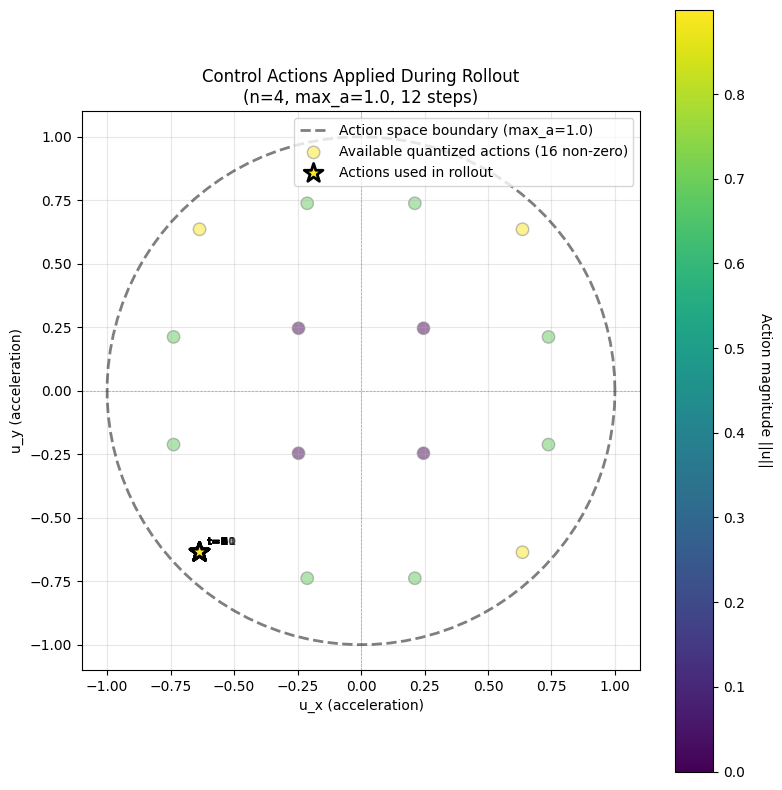

In [21]:
# Visualize control actions applied during rollout
import matplotlib.pyplot as plt
import numpy as np_cpu

# Extract the quantized actions that were actually used
u_seq_quantized = []
for t, u in enumerate(u_seq):
    uidx = bmdp.AQ.get_quantized_index(u)
    u_q = bmdp.AQ.U[uidx]
    u_seq_quantized.append(u_q)

u_seq_quantized = np_cpu.array([u.get() if hasattr(u, 'get') else np_cpu.asarray(u) for u in u_seq_quantized])

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot action space boundary (circle with radius max_a)
theta_circle = np_cpu.linspace(0, 2*np_cpu.pi, 100)
circle_x = motion_model.max_a * np_cpu.cos(theta_circle)
circle_y = motion_model.max_a * np_cpu.sin(theta_circle)
ax.plot(circle_x, circle_y, 'k--', linewidth=2, label=f'Action space boundary (max_a={motion_model.max_a})', alpha=0.5)

# Plot all available quantized actions
all_actions = bmdp.AQ.U.get() if hasattr(bmdp.AQ.U, 'get') else np_cpu.asarray(bmdp.AQ.U)
all_magnitudes = np_cpu.linalg.norm(all_actions, axis=1)

# Filter out actions very close to origin for cleaner visualization
origin_threshold = 1e-6
non_origin_mask = all_magnitudes > origin_threshold
origin_mask = all_magnitudes <= origin_threshold

if np_cpu.any(non_origin_mask):
    ax.scatter(all_actions[non_origin_mask, 0], all_actions[non_origin_mask, 1], 
               c=all_magnitudes[non_origin_mask], cmap='viridis', s=80, alpha=0.5, marker='o', 
               edgecolors='gray', linewidths=1, label=f'Available quantized actions ({np_cpu.sum(non_origin_mask)} non-zero)', zorder=1)

if np_cpu.any(origin_mask):
    print(f"Note: {np_cpu.sum(origin_mask)} quantized action(s) at/near origin (magnitude < {origin_threshold})")

# Plot the actions used in the rollout
magnitudes = np_cpu.linalg.norm(u_seq_quantized, axis=1)
scatter = ax.scatter(u_seq_quantized[:, 0], u_seq_quantized[:, 1], 
                    c=magnitudes, cmap='viridis', s=200, 
                    edgecolors='black', linewidths=2, 
                    marker='*', label='Actions used in rollout', zorder=3, vmin=0, vmax=np_cpu.max(all_magnitudes) if len(all_magnitudes) > 0 else 1)

# Add colorbar for magnitude
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Action magnitude ||u||', rotation=270, labelpad=20)

# Add text annotations for each action showing its index
for i, u in enumerate(u_seq_quantized):
    mag = magnitudes[i]
    if mag > origin_threshold:  # Only annotate non-zero actions
        ax.annotate(f't={i}', (u[0], u[1]), xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7, fontweight='bold')

ax.set_xlabel('u_x (acceleration)')
ax.set_ylabel('u_y (acceleration)')
ax.set_title(f'Control Actions Applied During Rollout\n(n={bmdp.AQ.n}, max_a={motion_model.max_a}, {len(u_seq_quantized)} steps)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)

# Print summary statistics
print(f"Action statistics:")
print(f"  Number of unique actions used: {len(np_cpu.unique(u_seq_quantized, axis=0))}")
print(f"  Mean magnitude: {np_cpu.mean(magnitudes):.4f}")
print(f"  Max magnitude: {np_cpu.max(magnitudes):.4f}")
print(f"  Min magnitude: {np_cpu.min(magnitudes):.4f}")
print(f"  Actions used: {u_seq_quantized.tolist()}")

plt.tight_layout()
plt.show()

In [ ]:
# Debug: how unique is the t=0 observation for the true state?
import numpy as np_cpu

state_idx0 = bmdp.SQ.get_quantized_index(x_history[1])
obs0 = obs_history[0].reshape(-1)
obs0_idx = bmdp._find_observation_indices(np.array([obs0]))[0]
obs0_q = bmdp.Y_n[obs0_idx]

# Compute y_star for all maps at this state
Y_star = bmdp._Q_y_star()
Y_star = Y_star.get() if hasattr(Y_star, 'get') else np_cpu.asarray(Y_star)
Y_star_state = Y_star[state_idx0]  # (len_M, L, 2)
Y_star_flat = Y_star_state.reshape(bmdp.len_M, -1)

mask = ~np_cpu.isnan(obs0_q)
delta = Y_star_flat[:, mask] - obs0_q[mask]
invalid = np_cpu.isnan(delta).any(axis=1)

# Distance on visible dims only
n_delta = np_cpu.nan_to_num(delta, nan=0.0)
dists = np_cpu.linalg.norm(n_delta, axis=1)
dists = np_cpu.where(invalid, np_cpu.inf, dists)

best_ids = np_cpu.argsort(dists)[:5]
print("t=0 state_idx:", int(state_idx0))
print("t=0 obs_idx:", int(obs0_idx))
print("t=0 true_map_id:", int(true_map_id))
print("t=0 min distances (top5):", [float(dists[i]) for i in best_ids])
print("t=0 best map ids:", best_ids.tolist())
print("t=0 true map distance:", float(dists[true_map_id]))


t=0 state_idx: 40
t=0 obs_idx: 11119
t=0 true_map_id: 11
t=0 min distances (top5): [0.7051170917539967, 1.218257178592661, 1.3259530202388727, 1.5005437787465763, 1.571976778868405]
t=0 best map ids: [11, 173, 92, 14, 17]
t=0 true map distance: 0.7051170917539967


In [ ]:
# Deep diagnostic: Compare true map's y_star vs actual observation
import numpy as np_cpu

state_idx0 = bmdp.SQ.get_quantized_index(x_history[1])
obs0 = obs_history[0].reshape(-1)  # Actual continuous observation
obs0_idx = bmdp._find_observation_indices(np.array([obs0]))[0]
obs0_q = bmdp.Y_n[obs0_idx]  # Quantized observation

# Get true map's expected observation at quantized state
Y_star = bmdp._Q_y_star()
Y_star = Y_star.get() if hasattr(Y_star, 'get') else np_cpu.asarray(Y_star)
Y_star_true = Y_star[state_idx0, true_map_id]  # (L, 2) - expected observation for true map

# Check what landmarks are actually in all_maps_3d for map_id=11
all_maps_3d = bmdp.all_maps_3d
all_maps_3d = all_maps_3d.get() if hasattr(all_maps_3d, 'get') else np_cpu.asarray(all_maps_3d)
true_map_from_all_maps = all_maps_3d[true_map_id]  # (L, 2)

# Also check what we expect from the map object
true_landmarks_expected = _map.get_landmark_positions(true_map)
true_landmarks_expected = true_landmarks_expected.get() if hasattr(true_landmarks_expected, 'get') else np_cpu.asarray(true_landmarks_expected)

# Compute distances from quantized state to landmarks
quantized_state_pos = bmdp.SQ.X_n[state_idx0, :2]
quantized_state_pos = quantized_state_pos.get() if hasattr(quantized_state_pos, 'get') else np_cpu.asarray(quantized_state_pos)

print("=== True Map Observation Diagnostic ===")
print(f"State idx: {state_idx0}")
print(f"Quantized state: {bmdp.SQ.X_n[state_idx0]}")
print(f"Quantized state position (x,y): {quantized_state_pos}")
print(f"True map id: {true_map_id}")
print(f"True map tuple: {true_map}")
print(f"\nLandmark positions:")
print(f"  Expected (from _map.get_landmark_positions): {true_landmarks_expected}")
print(f"  In all_maps_3d[{true_map_id}]: {true_map_from_all_maps}")
print(f"  Match: {np_cpu.allclose(true_landmarks_expected, true_map_from_all_maps)}")
print(f"\nDistances from quantized state to landmarks (r_max={sensor.r_max}):")
for i in range(3):
    dist_to_lm = np_cpu.linalg.norm(true_map_from_all_maps[i] - quantized_state_pos)
    in_range = (dist_to_lm >= sensor.epsilon) and (dist_to_lm <= sensor.r_max)
    print(f"  L{i+1} at {true_map_from_all_maps[i]}: dist={dist_to_lm:.4f}, in_range={in_range}")
print(f"\nActual continuous obs (from g_bar):")
print(f"  Shape: {obs0.shape}")
print(f"  Values: {obs0}")
print(f"\nQuantized obs (Y_n[{obs0_idx}]):")
print(f"  Shape: {obs0_q.shape}")
print(f"  Values: {obs0_q}")
print(f"\nTrue map's expected y_star (at quantized state):")
print(f"  Shape: {Y_star_true.shape}")
print(f"  Values: {Y_star_true}")
print(f"\nNaN comparison:")
print(f"  Actual obs has NaN: {np_cpu.isnan(obs0).any()}")
print(f"  Quantized obs has NaN: {np_cpu.isnan(obs0_q).any()}")
print(f"  y_star_true has NaN: {np_cpu.isnan(Y_star_true).any()}")
print(f"\nVisibility comparison (per landmark):")
for i in range(3):
    actual_vis = not (np_cpu.isnan(obs0[i*2]) or np_cpu.isnan(obs0[i*2+1]))
    quant_vis = not (np_cpu.isnan(obs0_q[i*2]) or np_cpu.isnan(obs0_q[i*2+1]))
    ystar_vis = not (np_cpu.isnan(Y_star_true[i, 0]) or np_cpu.isnan(Y_star_true[i, 1]))
    print(f"  L{i+1}: actual={actual_vis}, quantized={quant_vis}, y_star={ystar_vis}")
    if actual_vis and ystar_vis:
        print(f"    Actual: r={obs0[i*2]:.4f}, phi={obs0[i*2+1]:.4f}")
        print(f"    y_star: r={Y_star_true[i,0]:.4f}, phi={Y_star_true[i,1]:.4f}")
        print(f"    Diff:   r={abs(obs0[i*2] - Y_star_true[i,0]):.4f}, phi={abs(obs0[i*2+1] - Y_star_true[i,1]):.4f}")

=== True Map Observation Diagnostic ===
State idx: 40
Quantized state: [5.0000000e+00 5.0000000e+00 4.4408921e-16 4.4408921e-16]
Quantized state position (x,y): [5. 5.]
True map id: 11
True map tuple: [0 1 2]

Landmark positions:
  Expected (from _map.get_landmark_positions): [[1.66666667 1.66666667]
 [5.         1.66666667]
 [8.33333333 1.66666667]]
  In all_maps_3d[11]: [[1.66666667 1.66666667]
 [5.         1.66666667]
 [8.33333333 1.66666667]]
  Match: True

Distances from quantized state to landmarks (r_max=6.0):
  L1 at [1.66666667 1.66666667]: dist=4.7140, in_range=True
  L2 at [5.         1.66666667]: dist=3.3333, in_range=True
  L3 at [8.33333333 1.66666667]: dist=4.7140, in_range=True

Actual continuous obs (from g_bar):
  Shape: (6,)
  Values: [ 4.264436   -2.35619449  3.0321249  -1.46575212  4.73543775 -0.69030928]

Quantized obs (Y_n[11119]):
  Shape: (6,)
  Values: [ 4.525      -1.88495559  3.05       -1.88495559  4.525      -0.62831853]

True map's expected y_star (at qua

In [27]:
def create_landmark_evolution_gif(belief_history, positions, obs_history, bmdp, true_landmarks):
    """Animate ordered landmark belief over candidate positions."""
    import numpy as np_cpu

    M = bmdp.all_maps_3d
    if hasattr(M, 'get'):
        M = M.get()
    M = np_cpu.asarray(M)  # (len_M, l, 2)

    candidate_positions_raw = bmdp.map.landmark_positions
    candidate_positions = candidate_positions_raw.get() if hasattr(candidate_positions_raw, 'get') else np_cpu.asarray(candidate_positions_raw)

    num_candidates = candidate_positions.shape[0]
    num_landmarks = int(getattr(bmdp.map, 'num_landmarks', M.shape[1]))

    # Map each map's landmark positions to candidate indices
    diffs = M[:, :, np_cpu.newaxis, :] - candidate_positions[np_cpu.newaxis, np_cpu.newaxis, :, :]
    dist = np_cpu.linalg.norm(diffs, axis=3)
    idx = np_cpu.argmin(dist, axis=2)  # (len_M, l)

    eye = np_cpu.eye(num_candidates)
    one_hot = [eye[idx[:, i]] for i in range(num_landmarks)]

    # Precompute per-landmark candidate probabilities per step
    landmark_probs = []
    for pi_step in belief_history:
        pi_np = pi_step.get() if hasattr(pi_step, 'get') else np_cpu.asarray(pi_step)
        map_marginal = pi_np.sum(axis=0)
        map_marginal = map_marginal / map_marginal.sum()
        probs = [map_marginal @ one_hot[i] for i in range(num_landmarks)]
        landmark_probs.append(probs)

    fig, axes = plt.subplots(1, num_landmarks, figsize=(4 * num_landmarks, 4), sharex=True, sharey=True)
    if num_landmarks == 1:
        axes = [axes]

    left_lower = bmdp.map.left_lower
    right_upper = bmdp.map.right_upper
    left_lower = left_lower.get() if hasattr(left_lower, 'get') else np_cpu.asarray(left_lower)
    right_upper = right_upper.get() if hasattr(right_upper, 'get') else np_cpu.asarray(right_upper)

    true_landmarks_np = true_landmarks.get() if hasattr(true_landmarks, 'get') else np_cpu.asarray(true_landmarks)

    scatters = []
    pos_scatters = []
    scan_circles = []
    true_scatter = []
    obs_scatter = []
    perp_text = []

    for i, ax in enumerate(axes):
        ax.set_xlim(float(left_lower[0]), float(right_upper[0]))
        ax.set_ylim(float(left_lower[1]), float(right_upper[1]))
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Landmark {i + 1}')

        scat = ax.scatter(
            candidate_positions[:, 0],
            candidate_positions[:, 1],
            s=80,
            c=landmark_probs[0][i],
            cmap='viridis',
            vmin=0.0,
            vmax=1.0,
            edgecolors='black',
            alpha=0.9,
            zorder=2
        )
        scatters.append(scat)

        true_pt = ax.scatter(
            [true_landmarks_np[i, 0]],
            [true_landmarks_np[i, 1]],
            c='lime',
            marker='X',
            s=140,
            edgecolors='black',
            zorder=4,
            label='True landmark'
        )
        true_scatter.append(true_pt)

        obs_pt = ax.scatter([], [], c='red', marker='x', s=120, linewidths=2.0, zorder=6, label='Observed')
        obs_scatter.append(obs_pt)

        perp = ax.text(0.02, 0.95, '⊥', transform=ax.transAxes, fontsize=18, color='red',
                       verticalalignment='top', horizontalalignment='left', visible=False)
        perp_text.append(perp)

        pos_scatter = ax.scatter([], [], c='red', marker='*', s=160, edgecolors='black', label='Robot', zorder=5)
        pos_scatters.append(pos_scatter)

        scan_circle = plt.Circle((0, 0), bmdp.sensor.r_max, color='blue', fill=False, linestyle='--', alpha=0.4, zorder=1)
        ax.add_patch(scan_circle)
        scan_circles.append(scan_circle)

    cbar = fig.colorbar(scatters[0], ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label('P(landmark at candidate)')

    legend_handles = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markeredgecolor='black', markersize=10, label='Robot'),
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='lime', markeredgecolor='black', markersize=9, label='True landmark'),
        plt.Line2D([0], [0], marker='x', color='red', markersize=8, label='Observed'),
        plt.Line2D([0], [0], color='blue', linestyle='--', label='Scan range (r_max)')
    ]
    axes[0].legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

    # Convert positions to numpy array (like OGM version)
    positions_array = np_cpu.array([p.get() if hasattr(p, 'get') else np_cpu.asarray(p) for p in positions])
    obs_np = [o.get() if hasattr(o, 'get') else np_cpu.asarray(o) for o in obs_history]

    def animate(frame):
        probs = landmark_probs[frame]
        for i in range(num_landmarks):
            scatters[i].set_array(probs[i])
            sizes = 60 + 200 * probs[i]
            scatters[i].set_sizes(sizes)
            
            # Update robot position - show trajectory up to current frame (like OGM version)
            if frame < len(positions_array):
                current_positions = positions_array[:frame+1]
                pos_scatters[i].set_offsets(current_positions)
                # Get current position for scan circle (must be tuple)
                current_pos = positions_array[frame]
                scan_circles[i].center = (float(current_pos[0]), float(current_pos[1]))
            else:
                # Use last position if frame exceeds array length
                current_positions = positions_array
                pos_scatters[i].set_offsets(current_positions)
                last_pos = positions_array[-1]
                scan_circles[i].center = (float(last_pos[0]), float(last_pos[1]))

            # Update observation visualization
            if frame > 0 and frame - 1 < len(obs_np):
                obs = obs_np[frame - 1]
                if frame < len(positions_array):
                    pos = positions_array[frame]
                else:
                    pos = positions_array[-1]
                r, phi = obs[i, 0], obs[i, 1]
                if np_cpu.isnan(r) or np_cpu.isnan(phi):
                    obs_scatter[i].set_offsets(np_cpu.empty((0, 2)))
                    perp_text[i].set_visible(True)
                else:
                    obs_x = pos[0] + r * np_cpu.cos(phi)
                    obs_y = pos[1] + r * np_cpu.sin(phi)
                    obs_scatter[i].set_offsets([[obs_x, obs_y]])
                    perp_text[i].set_visible(False)
            else:
                obs_scatter[i].set_offsets(np_cpu.empty((0, 2)))
                perp_text[i].set_visible(False)

        return scatters + pos_scatters + scan_circles + true_scatter + obs_scatter + perp_text

    anim = FuncAnimation(fig, animate, frames=len(landmark_probs), interval=500, blit=False)
    html = HTML(anim.to_jshtml())
    plt.close(fig)
    return html

html_anim = create_landmark_evolution_gif(belief_history, positions, obs_history, bmdp, true_landmarks)
html_anim